In [1]:
import warnings
from rdkit import RDLogger

# 屏蔽 RDKit 警告
RDLogger.DisableLog('rdApp.*')

# 或屏蔽所有 Python 警告
warnings.filterwarnings("ignore")
# 屏蔽 LightGBM 警告
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

In [2]:
# -------------------- 基础与科学计算 --------------------
import os
import random
import warnings
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm
from scipy.stats import norm, pearsonr
from sklearn.exceptions import FitFailedWarning

# -------------------- 绘图与可视化 --------------------
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager as fm
from matplotlib.colors import LinearSegmentedColormap, Normalize
import seaborn as sns

# -------------------- 化学处理 --------------------
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

# -------------------- 特征工程与数据处理 --------------------
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder
)
from imblearn.over_sampling import RandomOverSampler

# -------------------- 降维与可视化 --------------------
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# -------------------- 机器学习模型 --------------------
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupKFold, RandomizedSearchCV, ParameterSampler
)
from sklearn.base import clone
from sklearn.metrics import (
    precision_recall_curve, auc, mean_squared_error, r2_score,
    mean_absolute_error, davies_bouldin_score
)

# -------------------- 深度学习 --------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

# -------------------- Transformer --------------------
from transformers import RobertaTokenizer, RobertaModel, BertTokenizerFast, BertModel

# -------------------- 超参优化 --------------------
import optuna

# -------------------- 其他工具 --------------------
import joblib


In [3]:
# 函数：将SMILES转换为分子描述符和指纹
def smiles_to_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    # 提取描述符
    descriptors = [
        Descriptors.MolWt(mol),  # 分子量
        Descriptors.MolLogP(mol),  # LogP
        Descriptors.NumHDonors(mol),  # 氢键供体数量
        Descriptors.NumHAcceptors(mol)  # 氢键受体数量
    ]
    # 生成Morgan指纹
    fingerprint = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    fingerprint_array = np.zeros((2048,))
    Chem.DataStructs.ConvertToNumpyArray(fingerprint, fingerprint_array)
    # 合并描述符和指纹
    features = np.concatenate([descriptors, fingerprint_array])
    return features


In [4]:
# 数据预处理
df = pd.read_excel('./fish_EC10_unique.xlsx')
labels = df['mgperL'].values
smiles_list = df['SMILES_Canonical_RDKit'].tolist()
endpoints_a = df['endpoint']
Duration_Values_a = df['Duration_Value'].values
effects_a = df['effect']


In [5]:

features = []
new_labels = []
new_smiles_list = []
endpoints = []
Duration_Values = []
effects =[]


for smiles, label,a,b,c in zip(smiles_list, labels,Duration_Values_a,effects_a,endpoints_a):
    feature = smiles_to_features(smiles)
    if feature is not None:
        features.append(feature)
        new_labels.append(label)
        new_smiles_list.append(smiles)
        Duration_Values.append(a)
        effects.append(b)
        endpoints.append(c)

X = np.array(features)
y = np.array(new_labels)
groups = new_smiles_list  # 可直接用于 GroupKFold




In [6]:
y=np.log1p(y)

In [7]:
smiles_embeddings = X
mgperL = y

In [8]:



# 根据 mgperL 浓度生成分类标签
def generate_labels(mgperL):
    """根据 mgperL 的浓度范围生成分类标签"""
    if mgperL < np.log1p(1):
        return 0  # high
    elif np.log1p(1) <= mgperL < np.log1p(10):
        return 1  # mid
    elif np.log1p(10) <= mgperL < np.log1p(100):
        return 2  # mid
    else:
        return 3  # low
# 生成分类标签    
classification_labels = [generate_labels(mg) for mg in mgperL]

# 假设 smiles_embeddings 是 [N, 768] 的词嵌入，classification_labels 是 [N] 的分类标签 (如 0,1,2,3)

# 使用 t-SNE 降维
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(smiles_embeddings)

# 直接使用离散标签作为分组
dbi_tsne = davies_bouldin_score(tsne_result, classification_labels)


In [9]:

# 指定字体文件路径
arial_font = fm.FontProperties(fname='../Arial//arial.ttf', size=80)


In [10]:


custom_palette = {
    0: "#c22f2f",  # 红
    1: "#ea7827",  # 黄
    2: "#1f70a9",  # 蓝
    3: "#449945",  # 绿
}

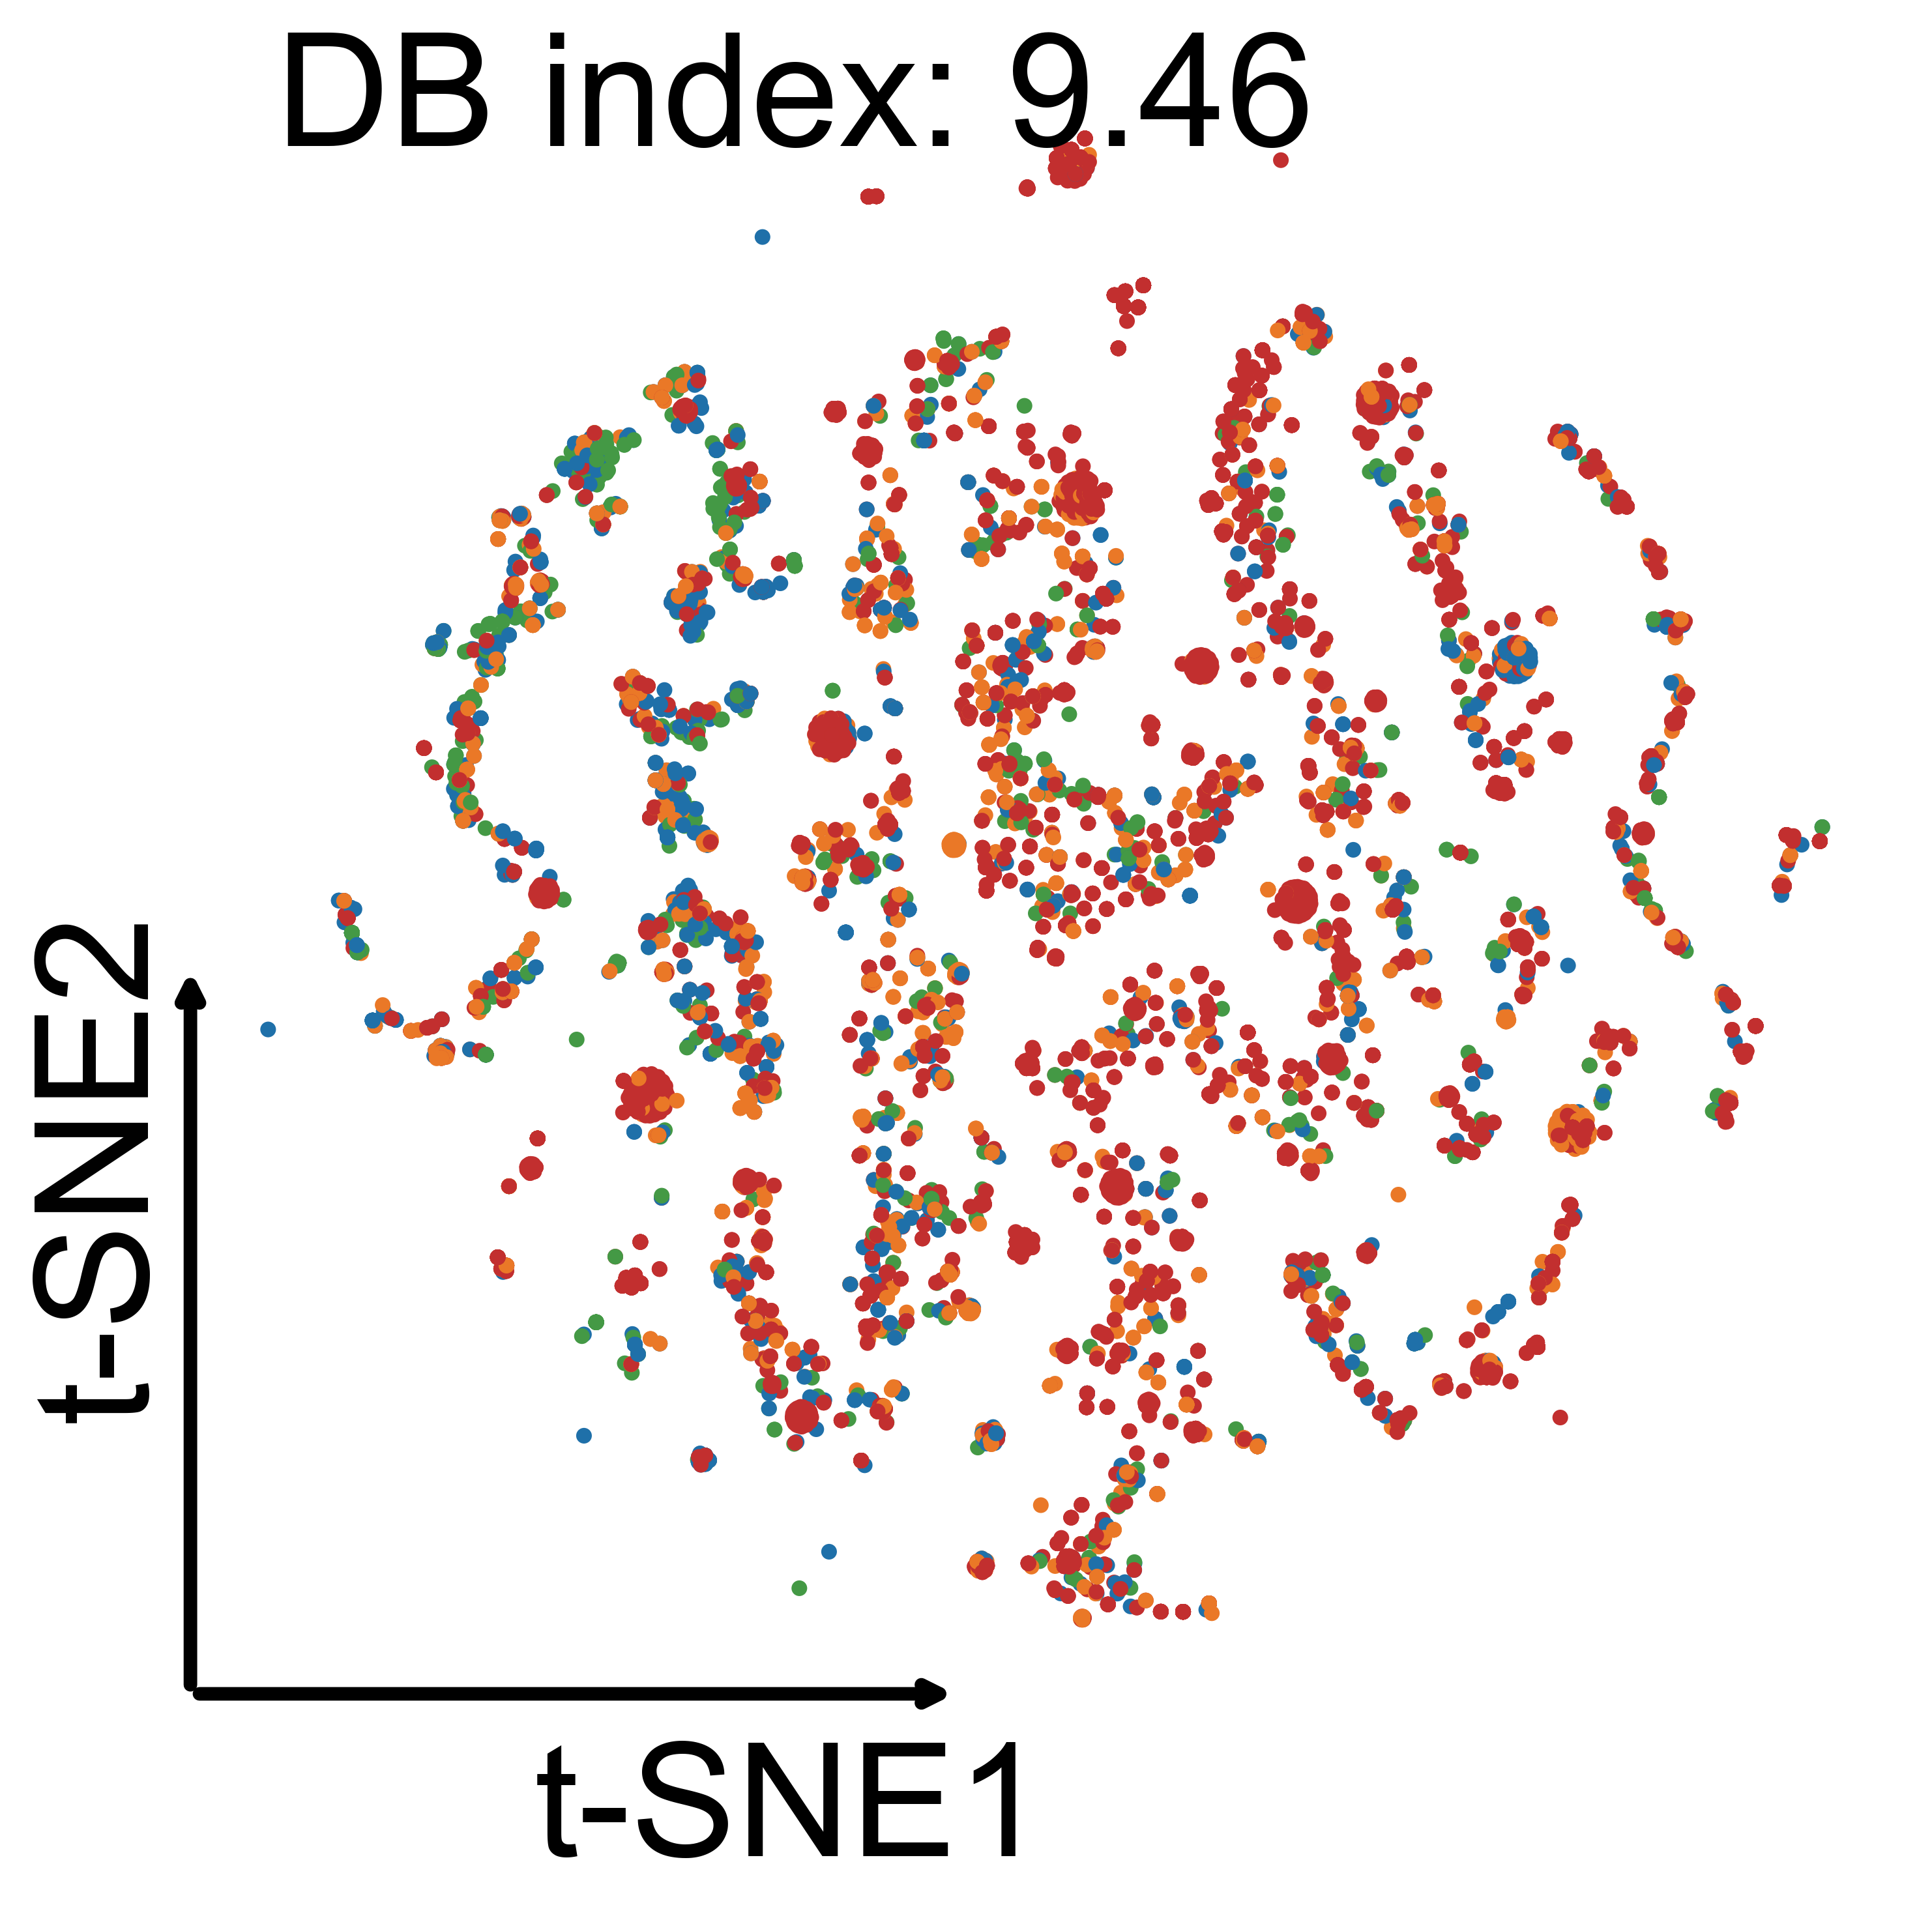

In [12]:
plt.figure(figsize=(6, 6), dpi=500)
sns.scatterplot(
    x=tsne_result[:, 0],
    y=tsne_result[:, 1],
    hue=classification_labels,
    palette=custom_palette,
    s=12,
    edgecolor=None,
    linewidth=0
)

# DB index 文本
plt.text(0.05, 0.95,
         f"DB index: {dbi_tsne:.2f}",
         transform=plt.gca().transAxes,
         fontsize=35,
         fontweight='bold',
         fontproperties=arial_font)

# 去掉图例
plt.legend([], [], frameon=False)

# 去掉默认坐标轴和边框
plt.axis('off')

# 获取边界
ax = plt.gca()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# 坐标轴原点设置为左下角
origin = (x_min, y_min)

# 箭头样式
arrow_props = dict(arrowstyle='->', linewidth=3, color='black', shrinkA=2, shrinkB=20)

# t-SNE1 箭头
arrow_x_end = x_min + (x_max - x_min) * 0.5
ax.annotate("", xy=(arrow_x_end, y_min), xytext=origin, arrowprops=arrow_props)

# t-SNE1 文本
ax.text(
    arrow_x_end, y_min - (y_max - y_min) * 0.03,  # 稍微下移，避免覆盖箭头
    "t-SNE1",
    fontsize=35,
    fontproperties=arial_font,
    ha='right',
    va='top',
    weight='bold'
)

# t-SNE2 箭头
arrow_y_end = y_min + (y_max - y_min) * 0.5
ax.annotate("", xy=(x_min, arrow_y_end), xytext=origin, arrowprops=arrow_props)

# t-SNE2 文本（稍微左移上移一点，避免“压住”箭头末端）
offset_x = (x_max - x_min) * 0.02
offset_y = (y_max - y_min) * 0.02
# t-SNE2 文本：向下移动，使得“末端”正好与箭头末端对齐
ax.text(
    x_min - (x_max - x_min) * 0.05,                              # 竖直文本的 x 坐标 = 箭头末端 x
    arrow_y_end - (y_max - y_min) * 0.02,  # y 坐标 = 箭头末端 y，稍微向下平移
    "t-SNE2",
    fontsize=35,
    fontproperties=arial_font,
    ha='center',    # 水平方向居中（相对于 x_min）
    va='top',       # 竖直方向对齐到“文本顶部”，这样它的底部正好对齐箭头末端
    weight='bold',
    rotation=90
)

plt.tight_layout()
plt.show()

In [13]:
smiles_embeddings = X
mgperL = y

In [14]:


# t-SNE 降维
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(smiles_embeddings)


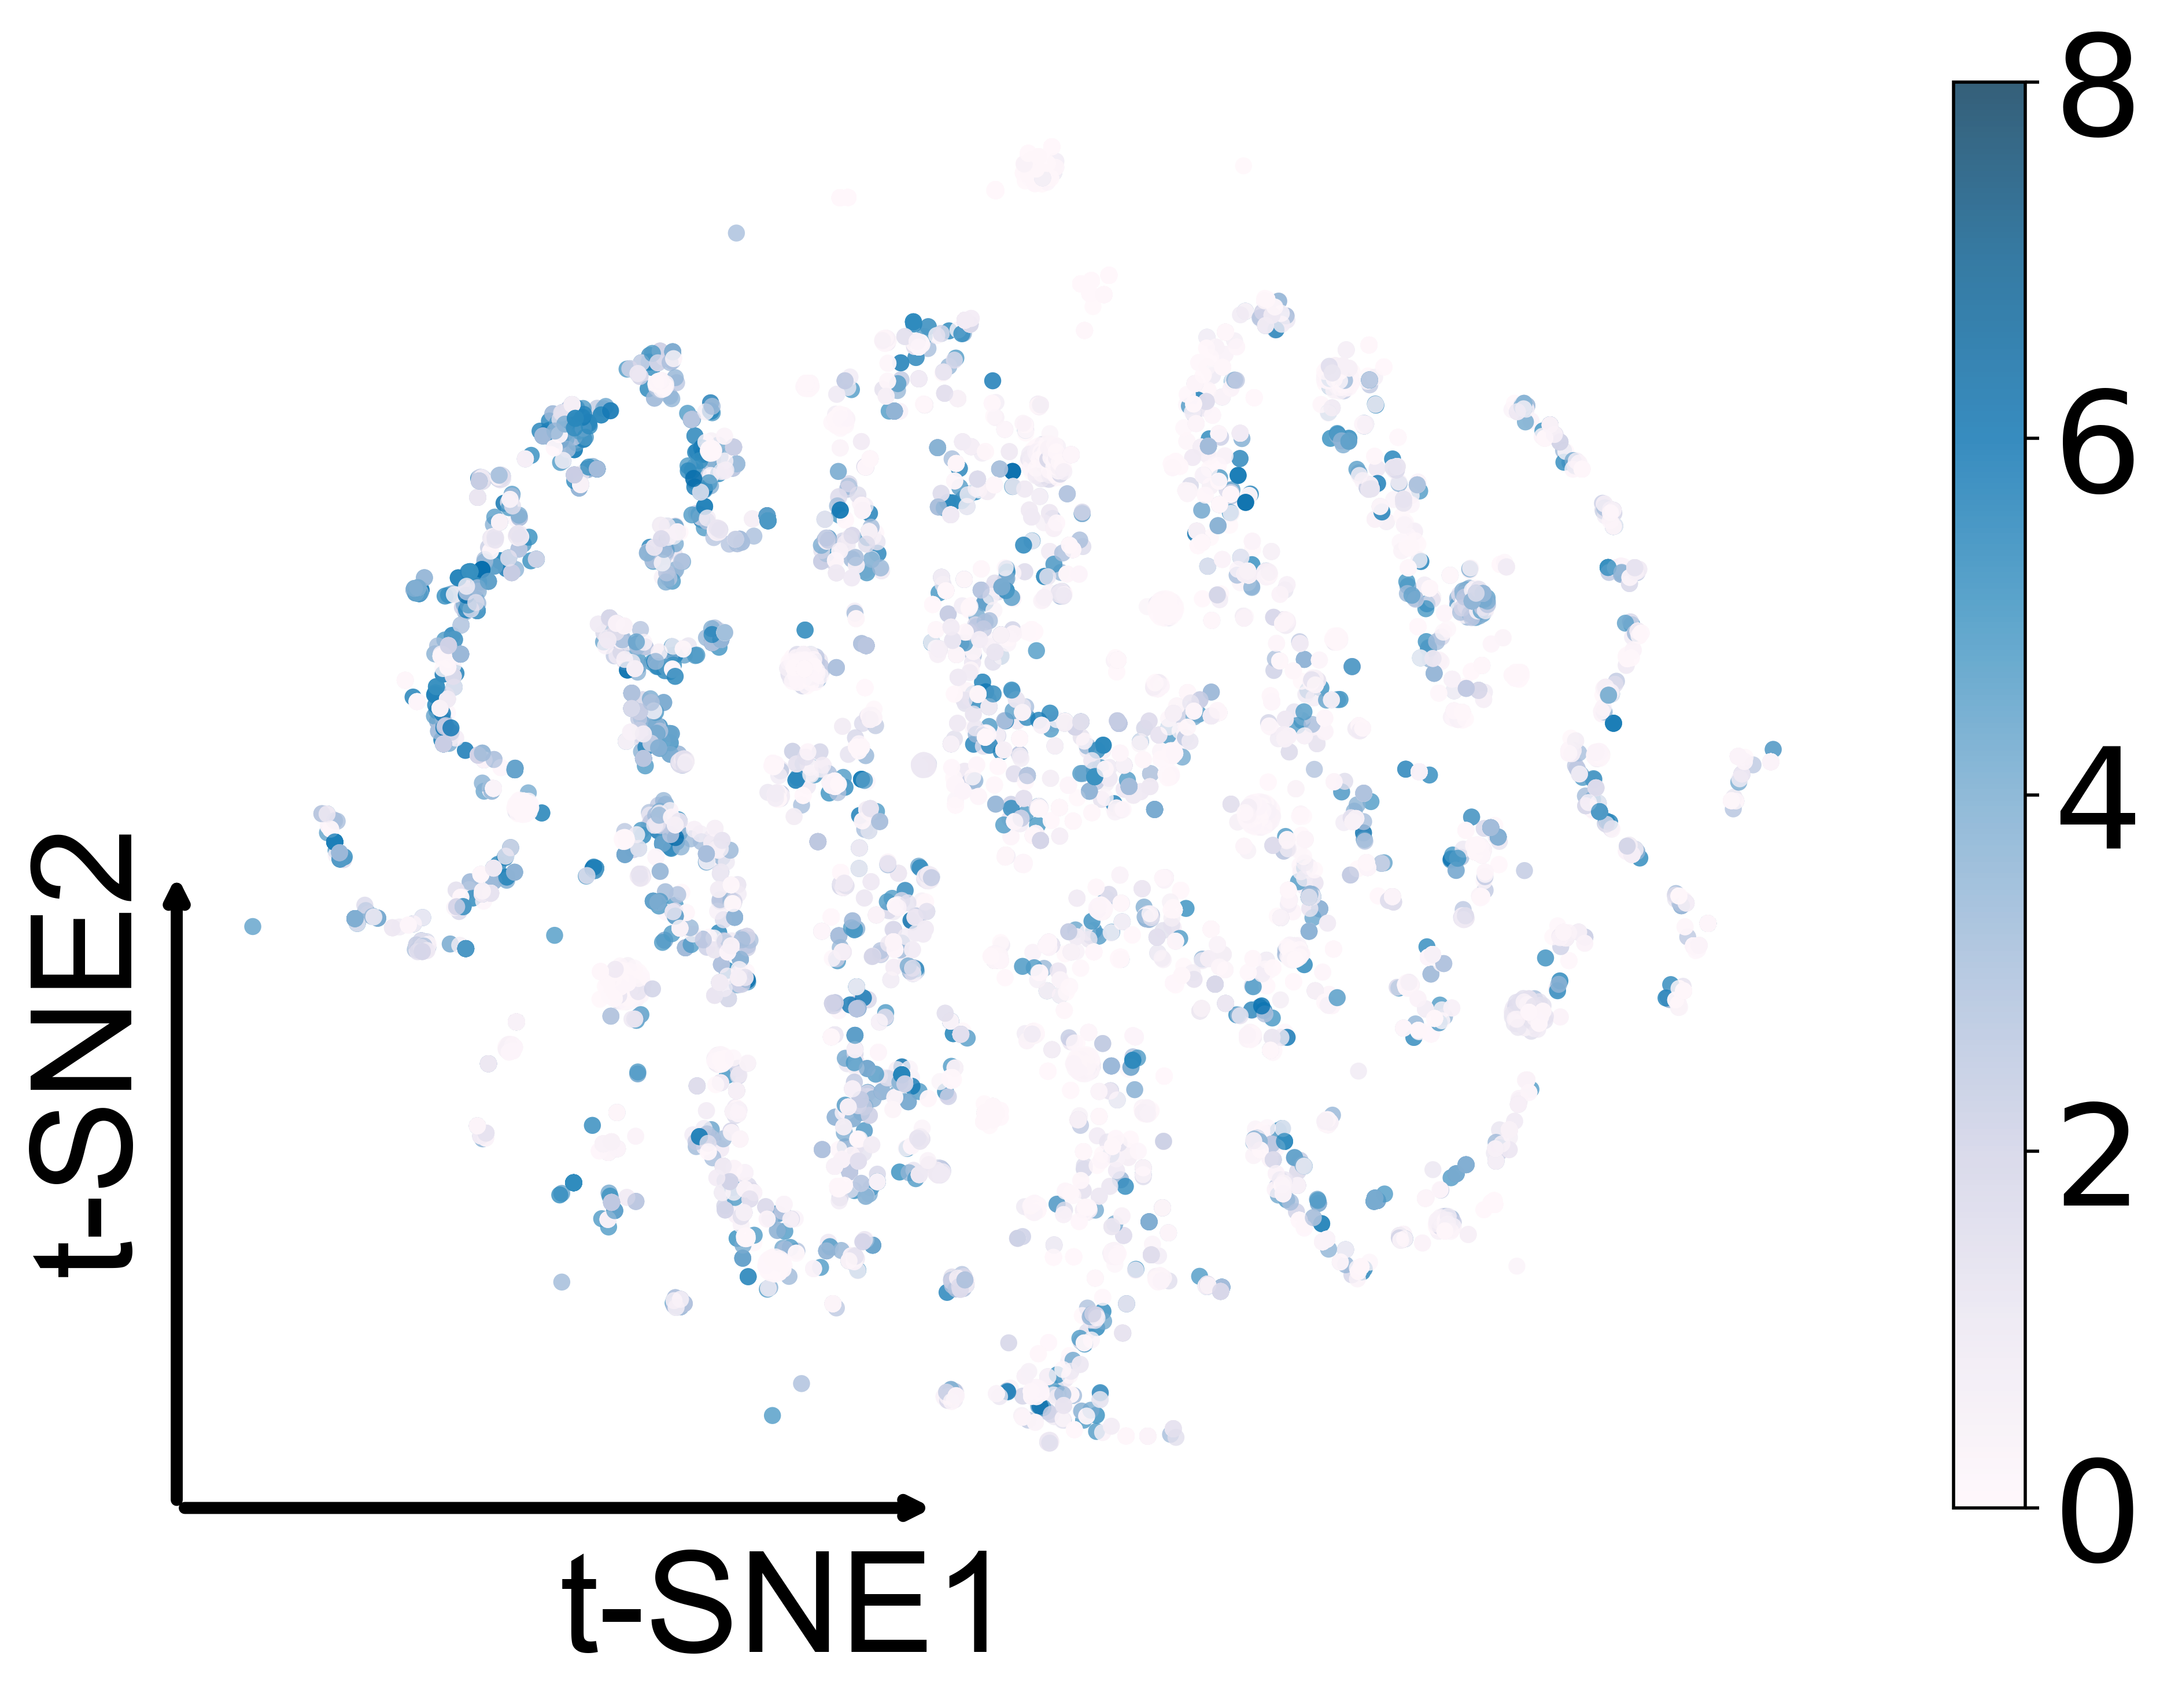

In [15]:

plt.figure(figsize=(8, 6), dpi=500)
sc = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=mgperL,
    cmap='PuBu',  # 使用自定义 cmap
    s=18,
    alpha=0.8,
    edgecolors='none',
    vmin=0,            # 颜色条下限
    vmax=8             # 颜色条上限
)

# 颜色条
cbar = plt.colorbar(sc)
#cbar.set_label('log1p(y)')
cbar.ax.tick_params(labelsize=35)
# 去掉图例
plt.legend([], [], frameon=False)

# 去掉默认坐标轴和边框
plt.axis('off')

# 获取边界
ax = plt.gca()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# 坐标轴原点设置为左下角
origin = (x_min, y_min)

# 箭头样式
arrow_props = dict(arrowstyle='->', linewidth=3, color='black', shrinkA=2, shrinkB=20)

# t-SNE1 箭头
arrow_x_end = x_min + (x_max - x_min) * 0.5
ax.annotate("", xy=(arrow_x_end, y_min), xytext=origin, arrowprops=arrow_props)

# t-SNE1 文本
ax.text(
    arrow_x_end, y_min - (y_max - y_min) * 0.03,  # 稍微下移，避免覆盖箭头
    "t-SNE1",
    fontsize=35,
    fontproperties=arial_font,
    ha='right',
    va='top',
    weight='bold'
)

# t-SNE2 箭头
arrow_y_end = y_min + (y_max - y_min) * 0.5
ax.annotate("", xy=(x_min, arrow_y_end), xytext=origin, arrowprops=arrow_props)

# t-SNE2 文本（稍微左移上移一点，避免“压住”箭头末端）
offset_x = (x_max - x_min) * 0.02
offset_y = (y_max - y_min) * 0.02
# t-SNE2 文本：向下移动，使得“末端”正好与箭头末端对齐
ax.text(
    x_min - (x_max - x_min) * 0.05,                              # 竖直文本的 x 坐标 = 箭头末端 x
    arrow_y_end - (y_max - y_min) * 0.02,  # y 坐标 = 箭头末端 y，稍微向下平移
    "t-SNE2",
    fontsize=35,
    fontproperties=arial_font,
    ha='center',    # 水平方向居中（相对于 x_min）
    va='top',       # 竖直方向对齐到“文本顶部”，这样它的底部正好对齐箭头末端
    weight='bold',
    rotation=90
)

plt.tight_layout()
plt.show()

In [16]:
data=pd.read_excel("./fish_EC10_unique.xlsx")
data=data.dropna()
smiles_data = data['SMILES_Canonical_RDKit'].tolist()
mgperL = data['mgperL'].values
Duration_Value= data['Duration_Value'].values

mgperL=np.log1p(mgperL)

In [17]:
# 检查需要One-Hot编码的列，并进行编码（如果类别超过一种）
def encode_column(data, column_name):
    unique_values = data[column_name].unique()
    if len(unique_values) > 1:
        encoder = OneHotEncoder(sparse_output=False)
        return encoder.fit_transform(data[[column_name]])
    else:
        return None  # 只有一种类别时忽略

# 编码 effect、endpoint 和 species_group 列
effect_encoded = encode_column(data, 'effect')
endpoint_encoded = encode_column(data, 'endpoint')
species_encoded = encode_column(data, 'species_group')

# 将需要的列拼接成输入 X
extra_features = data['Duration_Value'].values.reshape(-1, 1)

# 拼接编码后的列（如果存在）
for encoded_feature in [effect_encoded, endpoint_encoded, species_encoded]:
    if encoded_feature is not None:
        extra_features = np.hstack((extra_features, encoded_feature))


extra_dim = extra_features.shape[1]
data_extra_features = extra_features

In [18]:

# -------------------------------
# 1. 数据增强与 Dataset 修改：支持额外特征 extra_features
# -------------------------------
def augment_smiles(smiles):
    """简单的数据增强方法：50% 的概率翻转 SMILES 字符串"""
    if random.random() > 0.5:
        return smiles[::-1]
    return smiles

class SMILES_Dataset(Dataset):
    def __init__(self, smiles, reg_labels, extra_features=None, use_augmentation=False):
        self.smiles = smiles
        self.reg_labels = reg_labels
        self.extra_features = extra_features  # 额外特征，要求为数组或列表（每个元素是一个数值向量）
        self.use_augmentation = use_augmentation

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        s = self.smiles[idx]
        if self.use_augmentation:
            s = augment_smiles(s)
        reg_label = self.reg_labels[idx]
        tokens = tokenizer(s, padding='max_length', truncation=True, max_length=128, return_tensors="pt")
        # squeeze 扁平化 batch 维度（例如变为 [seq_len]）
        tokens = {key: val.squeeze(0) for key, val in tokens.items()}
        if self.extra_features is not None:
            extra_feat = self.extra_features[idx]
            extra_feat = torch.tensor(extra_feat, dtype=torch.float32)
            return tokens, torch.tensor(reg_label, dtype=torch.float32), extra_feat
        else:
            return tokens, torch.tensor(reg_label, dtype=torch.float32)


# -------------------------------
# 2. 加载本地 BERT 模型（BERT for SMILES）
# -------------------------------
# 请将 checkpoint 指向你的本地模型目录（此处示例使用 'unikei/bert-base-smiles'）
checkpoint = '../models/base_bert'
tokenizer = BertTokenizerFast.from_pretrained(checkpoint)
bert_model = BertModel.from_pretrained(checkpoint)

# -------------------------------
# 3. 模型定义：BERT_Regression
# -------------------------------
class Bert_Regression(nn.Module):
    def __init__(self, dropout_rate, fc1_size, fc2_size, fc3_size, extra_dim=0):
        """
        :param extra_dim: 额外特征维度，如果为 0 则不拼接额外特征
        """
        super(Bert_Regression, self).__init__()
        self.bert = bert_model  # 使用加载好的 BERT 模型
        hidden_size = self.bert.config.hidden_size  # 通常为768
        self.extra_dim = extra_dim
        # 拼接后的维度
        input_dim = hidden_size + extra_dim
        self.regressor = nn.Sequential(
            nn.Linear(input_dim, fc1_size),
            nn.ReLU(),
            nn.BatchNorm1d(fc1_size),
            nn.Dropout(dropout_rate),
            nn.Linear(fc1_size, fc2_size),
            nn.ReLU(),
            nn.BatchNorm1d(fc2_size),
            nn.Dropout(dropout_rate),
            nn.Linear(fc2_size, fc3_size),
            nn.ReLU(),
            nn.BatchNorm1d(fc3_size),
            nn.Dropout(dropout_rate),
            nn.Linear(fc3_size, 1),
            nn.Softplus()
        )
    
    def forward(self, tokens, extra_features=None):
        outputs = self.bert(**tokens)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # [CLS] token 嵌入，形状 [batch_size, 768]
        if self.extra_dim > 0 and extra_features is not None:
            # 拼接额外特征，要求 extra_features 的形状为 [batch_size, extra_dim]
            x = torch.cat([cls_embedding, extra_features], dim=1)
        else:
            x = cls_embedding
        reg_output = self.regressor(x)
        return reg_output

In [20]:
data_smiles = smiles_data
data_labels = mgperL

# 使用 SMILES 作为组依据，确保同一 SMILES 不出现在不同折中
groups = data_smiles

# 如果数据量较大，可根据需要提前封装为 Dataset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 3. 定义嵌入提取函数
def get_embeddings_for_loader(model, loader):
    all_embeddings = []
    all_extra_features = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for tokens, labels_tensor, extra_feats in loader:
            tokens = {key: val.to(device) for key, val in tokens.items()}
            extra_feats = extra_feats.to(device)
            outputs = model.bert(**tokens)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [B, 768]
            all_embeddings.append(cls_embeddings.cpu().numpy())
            all_extra_features.append(extra_feats.cpu().numpy())
            all_labels.append(labels_tensor.numpy())
    return (
        np.vstack(all_embeddings),
        np.vstack(all_extra_features),
        np.concatenate(all_labels)
    )

from sklearn.utils import shuffle


from torch.cuda.amp import autocast, GradScaler

# 直接使用之前超参数搜索得到的最优参数（保证与搜索阶段一致）
best_params = {
    'dropout_rate': 0.21744581463034474,
    'fc1_size': 640,
    'fc2_size': 160,
    'fc3_size': 192,
    'learning_rate': 1.1867190019710375e-05,
    'weight_decay': 0.02754170047562876
}
# 从 best_params 中提取各个超参数
best_dropout = best_params['dropout_rate']
best_fc1 = best_params['fc1_size']
best_fc2 = best_params['fc2_size']
best_fc3 = best_params['fc3_size']
best_lr = best_params['learning_rate']
best_wd = best_params['weight_decay']

# 构造数据集时仍传入dummy extra_features（比如全0）
dummy_extra = np.zeros((len(data_smiles), 7))  # 7是训练时额外特征的维度
full_dataset = SMILES_Dataset(data_smiles, data_labels, extra_features=dummy_extra)
full_loader = DataLoader(full_dataset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)

# 初始化模型（注意仍然使用原始训练结构）
model = Bert_Regression(best_dropout, best_fc1, best_fc2, best_fc3, extra_dim=7).to(device)
model.load_state_dict(torch.load('./optuna_model_set_1/bert_reg_fold_1.pth', map_location=device))
model.eval()

# 提取 SMILES 嵌入
smiles_emb, _, labels = get_embeddings_for_loader(model, full_loader)

# 保存
np.save('./k_folds_model/embeddings/X_all.npy', smiles_emb)
np.save('./k_folds_model/embeddings/y_all.npy', labels)

print("✅ SMILES embeddings（无extra特征参与）已成功保存")


✅ SMILES embeddings（无extra特征参与）已成功保存


In [21]:
# smiles_emb = np.load('./k_folds_model/embeddings/X_all.npy')
# labels = np.load('./k_folds_model/embeddings/y_all.npy')


In [22]:
smiles_embeddings = np.load('./k_folds_model/embeddings/X_all.npy')
mgperL = np.load('./k_folds_model/embeddings/y_all.npy')

In [23]:





# 根据 mgperL 浓度生成分类标签
def generate_labels(mgperL):
    """根据 mgperL 的浓度范围生成分类标签"""
    if mgperL < np.log1p(1):
        return 0  # high
    elif np.log1p(1) <= mgperL < np.log1p(10):
        return 1  # mid
    elif np.log1p(10) <= mgperL < np.log1p(100):
        return 2  # mid
    else:
        return 3  # low
# 生成分类标签    
classification_labels = [generate_labels(mg) for mg in mgperL]



# 假设 smiles_embeddings 是 [N, 768] 的词嵌入，classification_labels 是 [N] 的分类标签 (如 0,1,2,3)

# 使用 t-SNE 降维
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(smiles_embeddings)

# 直接使用离散标签作为分组
dbi_tsne = davies_bouldin_score(tsne_result, classification_labels)

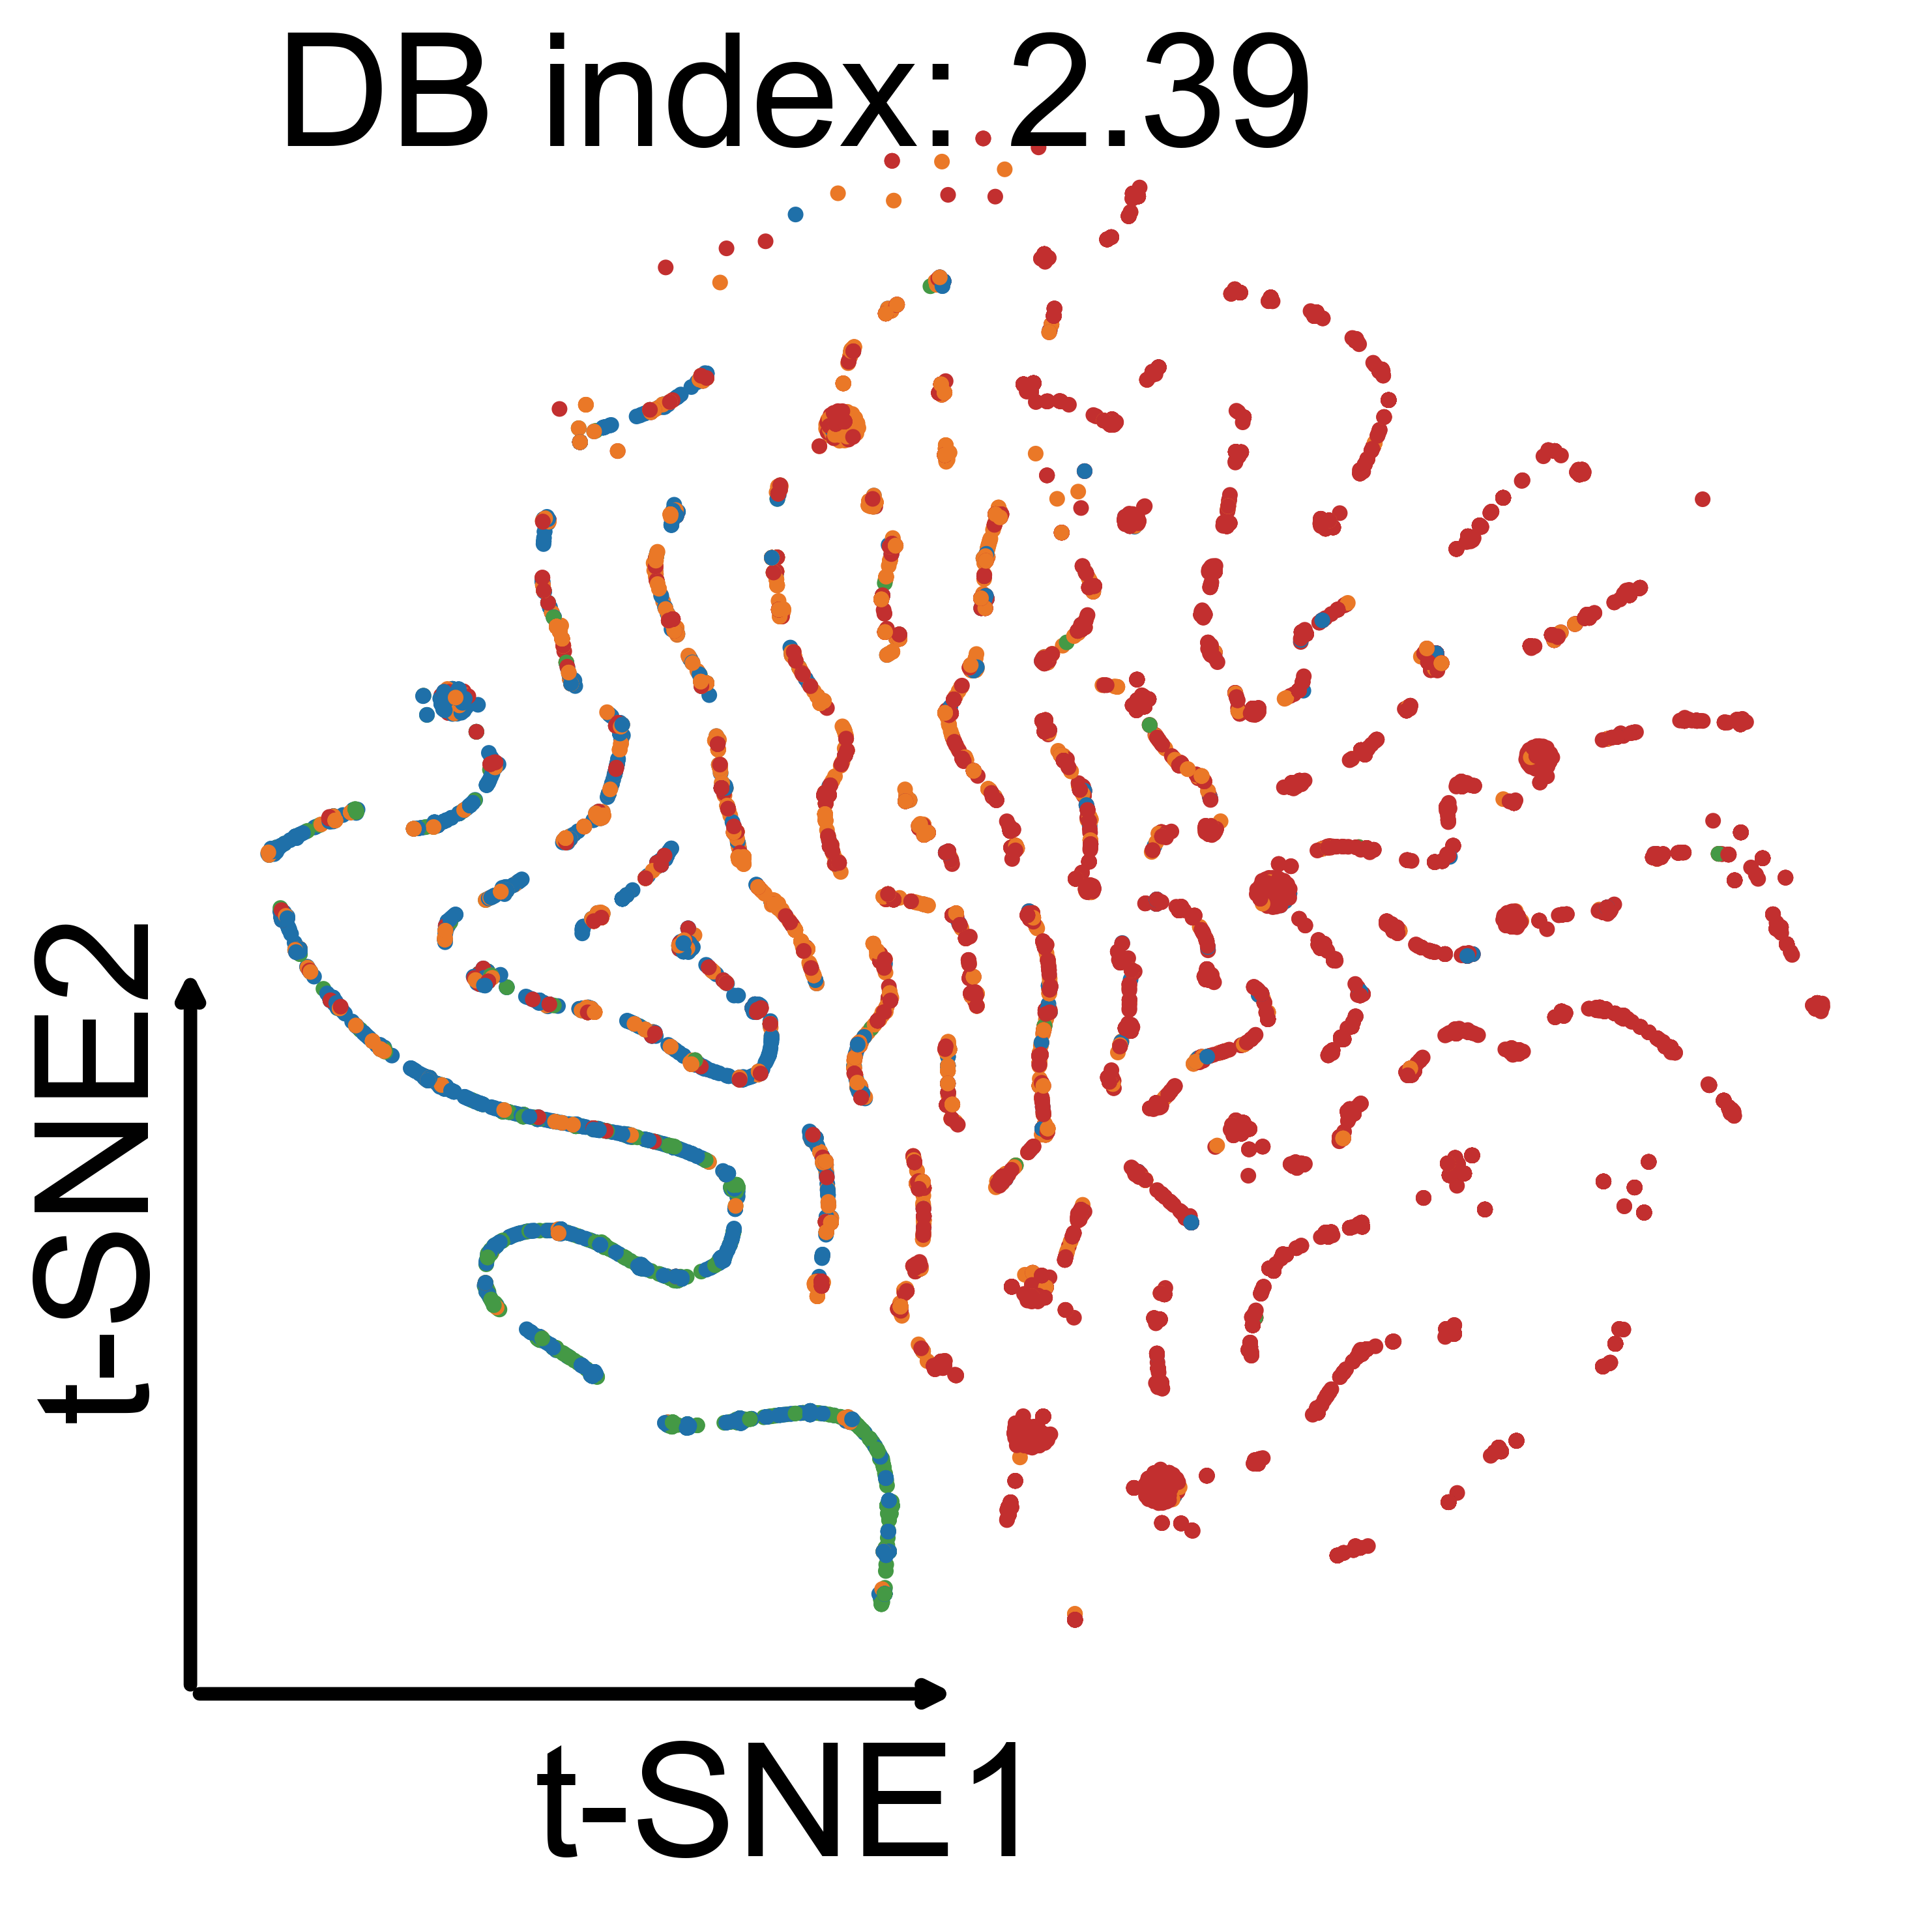

In [24]:
plt.figure(figsize=(6, 6), dpi=500)
sns.scatterplot(
    x=tsne_result[:, 0],
    y=tsne_result[:, 1],
    hue=classification_labels,
    palette=custom_palette,
    s=12,
    edgecolor=None,
    linewidth=0
)

# DB index 文本
plt.text(0.05, 0.95,
         f"DB index: {dbi_tsne:.2f}",
         transform=plt.gca().transAxes,
         fontsize=35,
         fontweight='bold',
         fontproperties=arial_font)

# 去掉图例
plt.legend([], [], frameon=False)

# 去掉默认坐标轴和边框
plt.axis('off')

# 获取边界
ax = plt.gca()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# 坐标轴原点设置为左下角
origin = (x_min, y_min)

# 箭头样式
arrow_props = dict(arrowstyle='->', linewidth=3, color='black', shrinkA=2, shrinkB=20)

# t-SNE1 箭头
arrow_x_end = x_min + (x_max - x_min) * 0.5
ax.annotate("", xy=(arrow_x_end, y_min), xytext=origin, arrowprops=arrow_props)

# t-SNE1 文本
ax.text(
    arrow_x_end, y_min - (y_max - y_min) * 0.03,  # 稍微下移，避免覆盖箭头
    "t-SNE1",
    fontsize=35,
    fontproperties=arial_font,
    ha='right',
    va='top',
    weight='bold'
)

# t-SNE2 箭头
arrow_y_end = y_min + (y_max - y_min) * 0.5
ax.annotate("", xy=(x_min, arrow_y_end), xytext=origin, arrowprops=arrow_props)

# t-SNE2 文本（稍微左移上移一点，避免“压住”箭头末端）
offset_x = (x_max - x_min) * 0.02
offset_y = (y_max - y_min) * 0.02
# t-SNE2 文本：向下移动，使得“末端”正好与箭头末端对齐
ax.text(
    x_min - (x_max - x_min) * 0.05,                              # 竖直文本的 x 坐标 = 箭头末端 x
    arrow_y_end - (y_max - y_min) * 0.02,  # y 坐标 = 箭头末端 y，稍微向下平移
    "t-SNE2",
    fontsize=35,
    fontproperties=arial_font,
    ha='center',    # 水平方向居中（相对于 x_min）
    va='top',       # 竖直方向对齐到“文本顶部”，这样它的底部正好对齐箭头末端
    weight='bold',
    rotation=90
)

plt.tight_layout()
plt.show()

In [25]:
smiles_embeddings = np.load('./k_folds_model/embeddings/X_all.npy')
mgperL = np.load('./k_folds_model/embeddings/y_all.npy')

In [26]:

# t-SNE 降维
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(smiles_embeddings)


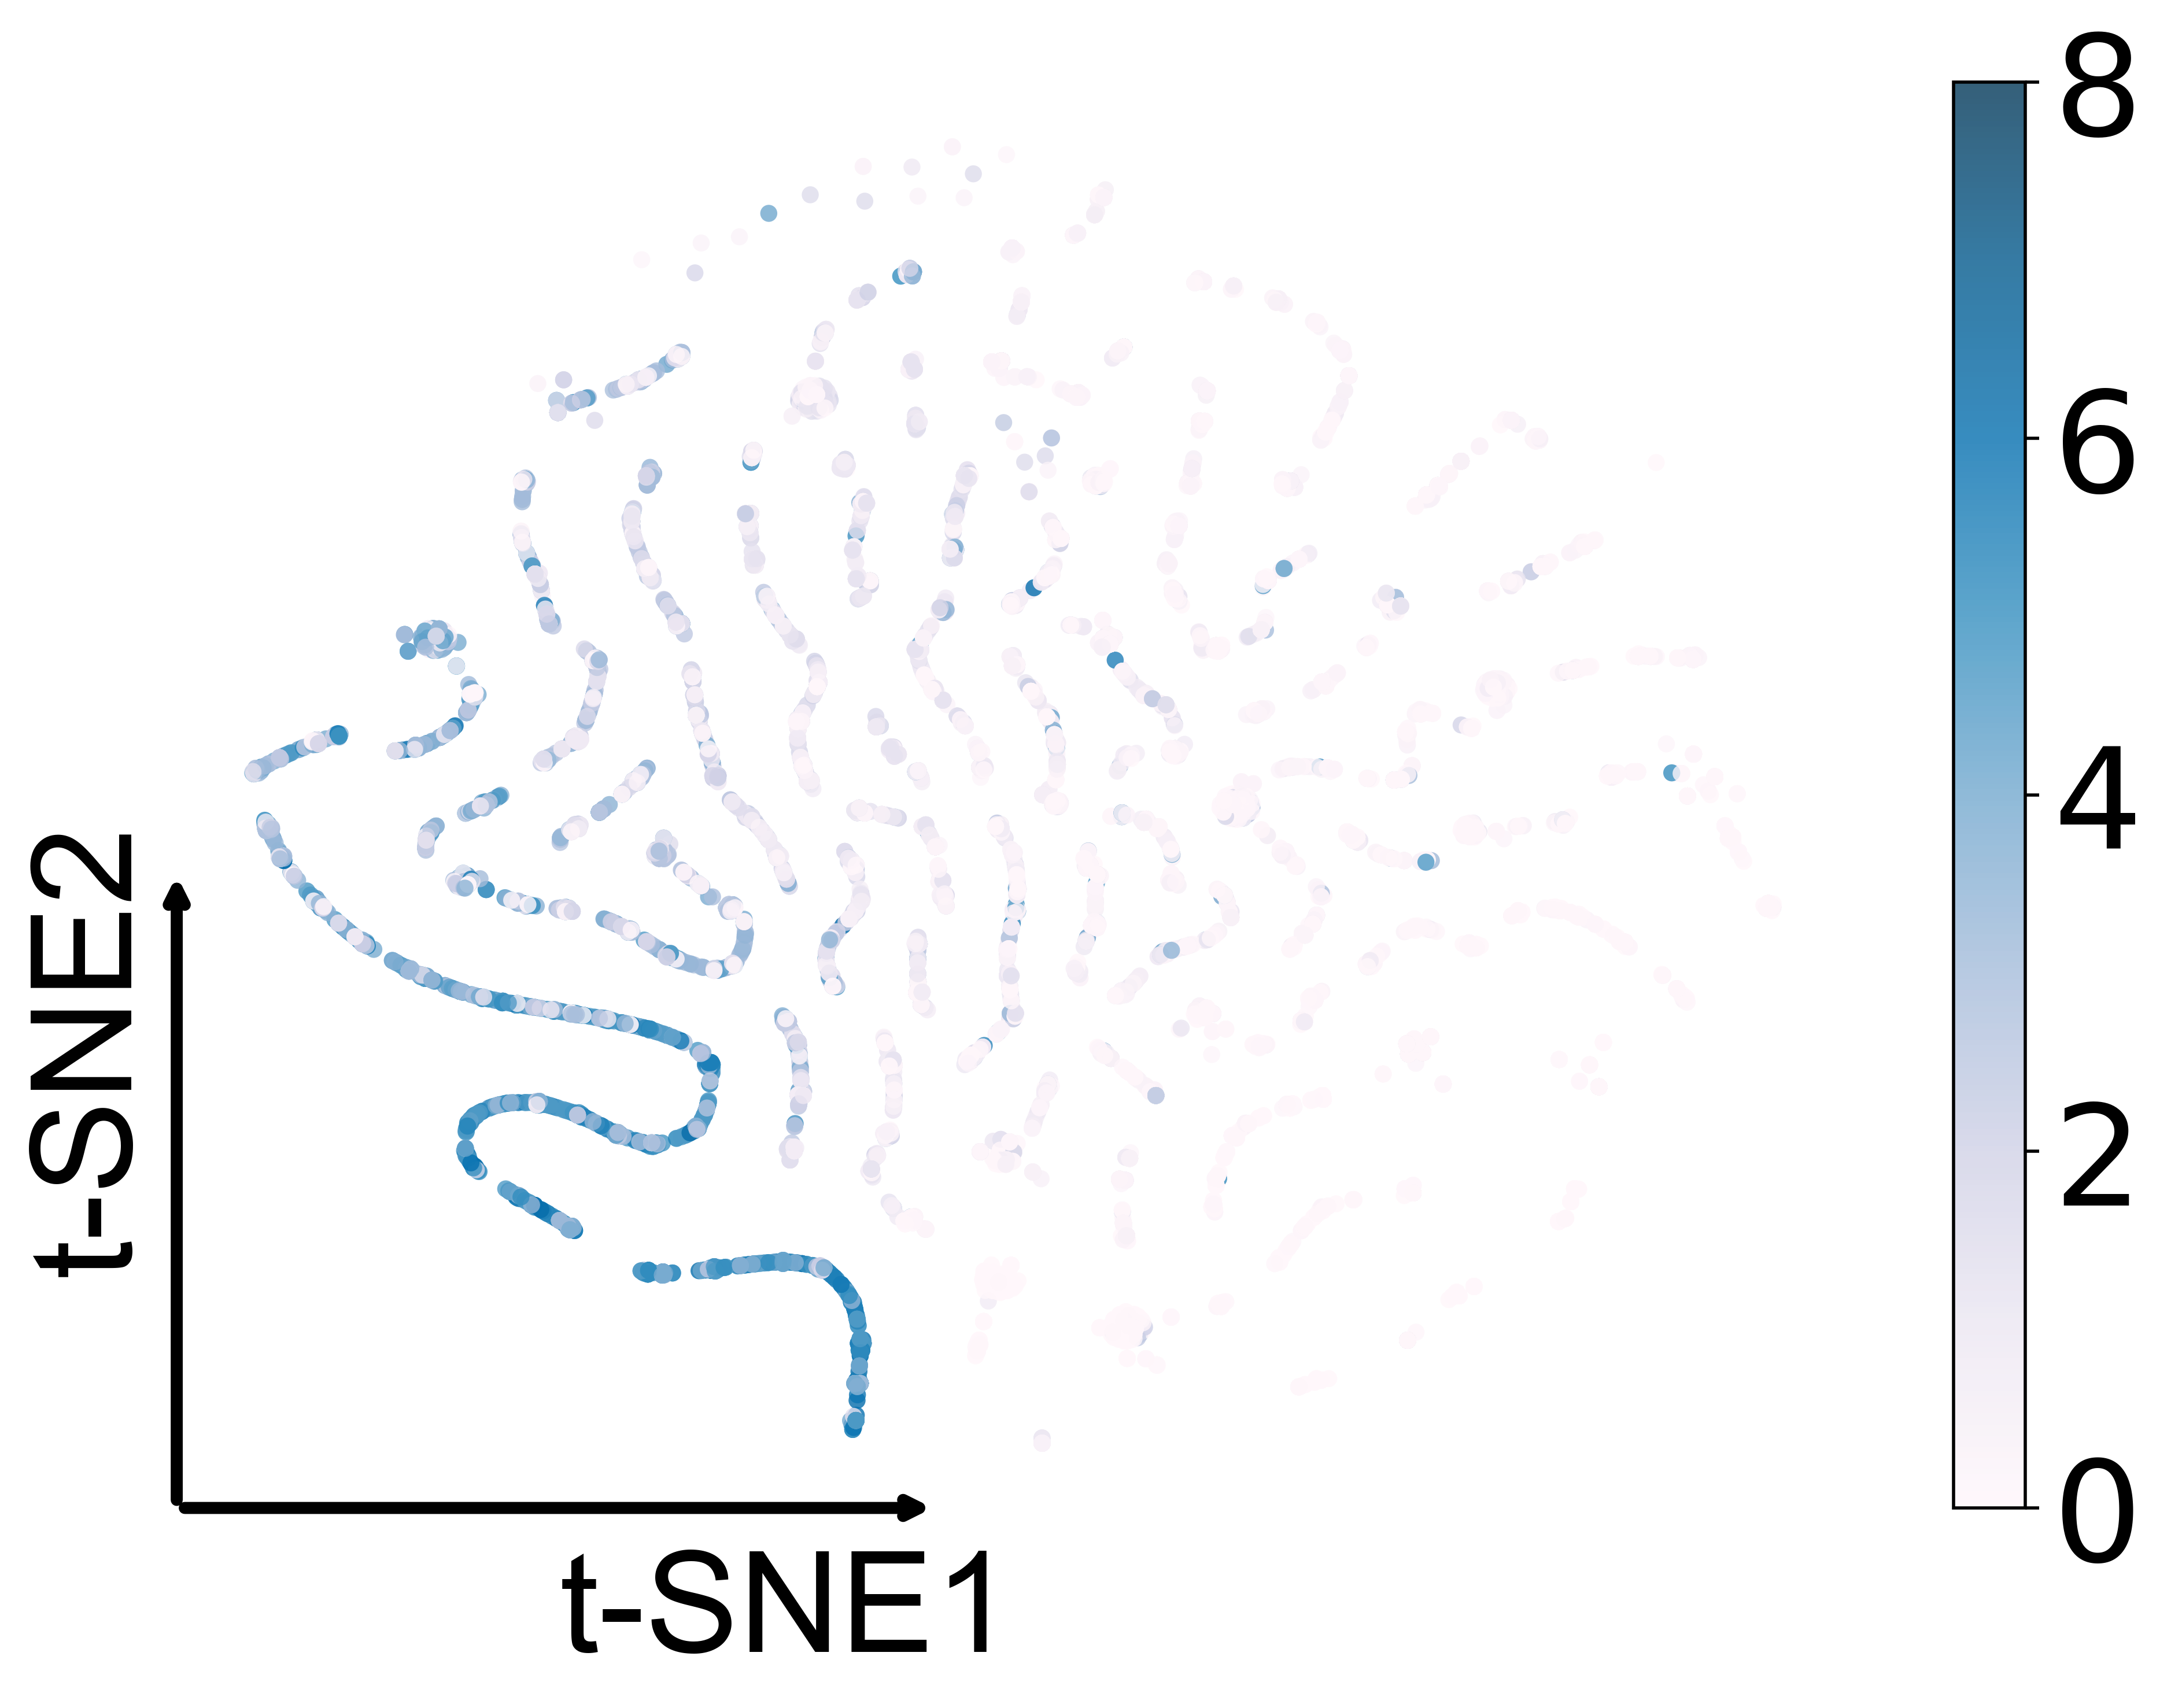

In [27]:

plt.figure(figsize=(8, 6), dpi=500)
sc = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=mgperL,
    cmap='PuBu',   # 使用自定义 cmap
    s=18,
    alpha=0.8,
    edgecolors='none',
    vmin=0,            # 颜色条下限
    vmax=8             # 颜色条上限
)

# 颜色条
cbar = plt.colorbar(sc)
#cbar.set_label('log1p(y)')
cbar.ax.tick_params(labelsize=35)
# 去掉图例
plt.legend([], [], frameon=False)

# 去掉默认坐标轴和边框
plt.axis('off')

# 获取边界
ax = plt.gca()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# 坐标轴原点设置为左下角
origin = (x_min, y_min)

# 箭头样式
arrow_props = dict(arrowstyle='->', linewidth=3, color='black', shrinkA=2, shrinkB=20)

# t-SNE1 箭头
arrow_x_end = x_min + (x_max - x_min) * 0.5
ax.annotate("", xy=(arrow_x_end, y_min), xytext=origin, arrowprops=arrow_props)

# t-SNE1 文本
ax.text(
    arrow_x_end, y_min - (y_max - y_min) * 0.03,  # 稍微下移，避免覆盖箭头
    "t-SNE1",
    fontsize=35,
    fontproperties=arial_font,
    ha='right',
    va='top',
    weight='bold'
)

# t-SNE2 箭头
arrow_y_end = y_min + (y_max - y_min) * 0.5
ax.annotate("", xy=(x_min, arrow_y_end), xytext=origin, arrowprops=arrow_props)

# t-SNE2 文本（稍微左移上移一点，避免“压住”箭头末端）
offset_x = (x_max - x_min) * 0.02
offset_y = (y_max - y_min) * 0.02
# t-SNE2 文本：向下移动，使得“末端”正好与箭头末端对齐
ax.text(
    x_min - (x_max - x_min) * 0.05,                              # 竖直文本的 x 坐标 = 箭头末端 x
    arrow_y_end - (y_max - y_min) * 0.02,  # y 坐标 = 箭头末端 y，稍微向下平移
    "t-SNE2",
    fontsize=35,
    fontproperties=arial_font,
    ha='center',    # 水平方向居中（相对于 x_min）
    va='top',       # 竖直方向对齐到“文本顶部”，这样它的底部正好对齐箭头末端
    weight='bold',
    rotation=90
)

plt.tight_layout()
plt.show()